# 🏦 XGBoost Credit Risk Model & Explainable AI (SHAP)
**Goal:** Build a production-grade XGBoost model to predict loan defaults, optimizing for recall to minimize financial loss.
**Key Skills:** Handling extreme outliers, XGBoost native missing value handling, Hyperparameter Tuning (GridSearchCV), Early Stopping, and Explainable AI (SHAP).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Credit Scoring dataset from a stable repository
url = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-06-trees/CreditScoring.csv"
df = pd.read_csv(url)

In [2]:
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


## 1. Data Cleaning & XGBoost Preprocessing
Financial data often contains hardcoded errors. Here, we replace placeholder outliers (`99999999`) with true `NaN` values. Unlike standard algorithms, XGBoost uses a Sparsity-Aware Split Finding algorithm, allowing us to leave `NaN` values intact without injecting human bias via mean/median imputation. We also explicitly calculate the class imbalance ratio.

In [3]:


# The dataset uses text for some categorical columns, let's make them lowercase for easier coding
df.columns = df.columns.str.lower()

# 2. Inspect the Target Variable ('status')
# In this raw dataset: 1 = Good Loan (Paid), 2 = Default (Failed), 0 = Unknown
# Let's filter out the unknown 0s, and map it to standard binary: 0 = Paid, 1 = Default
df = df[df['status'] != 0].copy()
df['status'] = df['status'].map({1: 0, 2: 1})

# 3. Check the Class Imbalance
imbalance = df['status'].value_counts(normalize=True) * 100

print("--- LOAN DEFAULT DISTRIBUTION ---")
print(f"Paid Loans (0):    {imbalance[0]:.2f}%")
print(f"Defaulted (1):     {imbalance[1]:.2f}%")
print(f"\nTotal Records: {len(df)}")



--- LOAN DEFAULT DISTRIBUTION ---
Paid Loans (0):    71.85%
Defaulted (1):     28.15%

Total Records: 4454


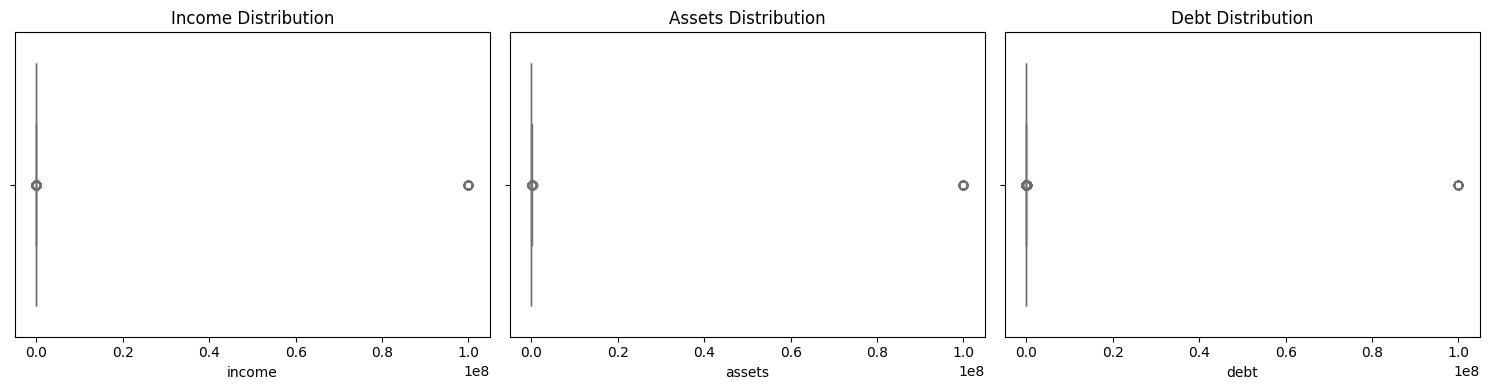


--- MAXIMUM VALUES FOUND ---
Max Income: 99999999
Max Assets: 99999999
Max Debt:   99999999


In [9]:
# Replace the placeholder '99999999' with true missing values (NaN)
for col in ['income', 'assets', 'debt']:
    df[col] = df[col].replace(99999999, np.nan)

print(f"Total missing values in Income: {df['income'].isna().sum()}")
print(f"Total missing values in Assets: {df['assets'].isna().sum()}")
print(f"Total missing values in Debt:   {df['debt'].isna().sum()}")
print("\nOutliers removed! Data is now reflecting reality.")

Total missing values in Income: 34
Total missing values in Assets: 47
Total missing values in Debt:   18

Outliers removed! Data is now reflecting reality.


In [10]:
df['income'].sort_values(ascending=False)

,income
806,959.0
1427,905.0
2007,857.0
754,830.0
920,800.0
...,...
3850,NaN
4076,NaN
4119,NaN
4223,NaN


## 2. Hyperparameter Tuning & Early Stopping
XGBoost is highly prone to overfitting if unchecked. We use `GridSearchCV` to find the optimal tree depth and learning rate. Crucially, we utilize `scale_pos_weight` to mathematically penalize the model for missing defaults, and implement `early_stopping_rounds` to halt training the moment validation accuracy plateaus.

In [13]:
from sklearn.model_selection import train_test_split

# 1. Identify the categorical columns
categorical_cols = ['home', 'marital', 'records', 'job']

# Convert them from misleading integers to strings so Pandas knows they are categories
for col in categorical_cols:
    df[col] = df[col].astype(str)

# 2. Separate Features (X) and Target (y)
X = df.drop('status', axis=1)
y = df['status']

# 3. One-Hot Encoding
# This translates our categories into the binary 0s and 1s XGBoost needs
X_encoded = pd.get_dummies(X, drop_first=True)

# 4. Train / Test Split (Crucial step!)
# We use stratify=y to ensure both sets keep the exact 72/28 imbalance ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Original number of columns: {X.shape[1]}")
print(f"New encoded number of columns: {X_train.shape[1]}\n")

# Let's prove the NaNs are still there and the model is about to accept them!
print(f"Missing values in X_train Income: {X_train['income'].isna().sum()}")
display(X_train.head(3))

Original number of columns: 13
New encoded number of columns: 25

Missing values in X_train Income: 29


,seniority,time,age,expenses,income,assets,debt,amount,price,home_1,...,marital_1,marital_2,marital_3,marital_4,marital_5,records_2,job_1,job_2,job_3,job_4
478,15,48,34,45,0.0,5000.0,0.0,900,1197,False,...,False,False,False,True,False,False,False,False,True,False
39,30,60,64,45,120.0,14000.0,0.0,1125,1300,False,...,False,True,False,False,False,False,True,False,False,False
2449,2,60,23,35,106.0,0.0,0.0,820,1097,False,...,True,False,False,False,False,False,True,False,False,False


In [14]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# 1. Calculate the exact imbalance ratio for 'scale_pos_weight'
# Formula: Count of Negative Class (0) / Count of Positive Class (1)
neg_class_count = sum(y_train == 0)
pos_class_count = sum(y_train == 1)
imbalance_ratio = neg_class_count / pos_class_count

print(f"Calculated scale_pos_weight: {imbalance_ratio:.2f}\n")

# 2. Initialize the baseline XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    random_state=42,
    scale_pos_weight=imbalance_ratio,
    eval_metric='logloss' # Standard evaluation metric for binary classification
)

# 3. Define the Hyperparameter Grid
# (We keep this grid relatively small so Colab finishes quickly!)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

# 4. Set up GridSearchCV
# We set scoring='recall' because in banking, missing a default (False Negative) is catastrophic!
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='recall',
    cv=3,
    verbose=1 # Prints the progress so we know it isn't frozen
)

# 5. Run the search on the training data
print("Starting Grid Search... (This might take 30-60 seconds)\n")
grid_search.fit(X_train, y_train)

# 6. Save the winning model
best_xgb = grid_search.best_estimator_

print("\n--- GRID SEARCH COMPLETE ---")
print(f"Best Parameters Found: {grid_search.best_params_}")

Calculated scale_pos_weight: 2.55

Starting Grid Search... (This might take 30-60 seconds)

Fitting 3 folds for each of 27 candidates, totalling 81 fits

--- GRID SEARCH COMPLETE ---
Best Parameters Found: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


In [15]:
# 1. Initialize a new model using the best parameters from our Grid Search
# We also pass 'early_stopping_rounds=10' directly into the model constructor
final_xgb = xgb.XGBClassifier(
    **grid_search.best_params_,  # Unpacks the winning max_depth, learning_rate, etc.
    random_state=42,
    scale_pos_weight=imbalance_ratio,
    early_stopping_rounds=10,
    eval_metric='logloss'
)

# 2. Train the model with Early Stopping
# We MUST provide an 'eval_set' so the model has unseen data to test itself on after every tree
print("Training Final XGBoost Model with Early Stopping...\n")

final_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)], # We track both Train and Test to watch for overfitting
    verbose=10 # Print the score every 10 trees so we don't spam the console
)

# 3. Check exactly when the model decided to stop
best_iteration = final_xgb.best_iteration
print(f"\nTraining stopped! The optimal model was found at tree #{best_iteration}.")

Training Final XGBoost Model with Early Stopping...

[0]	validation_0-logloss:0.69085	validation_1-logloss:0.69089
[10]	validation_0-logloss:0.67000	validation_1-logloss:0.67053
[20]	validation_0-logloss:0.65231	validation_1-logloss:0.65348
[30]	validation_0-logloss:0.63685	validation_1-logloss:0.63884
[40]	validation_0-logloss:0.62380	validation_1-logloss:0.62647
[50]	validation_0-logloss:0.61200	validation_1-logloss:0.61521
[60]	validation_0-logloss:0.60138	validation_1-logloss:0.60522
[70]	validation_0-logloss:0.59194	validation_1-logloss:0.59656
[80]	validation_0-logloss:0.58332	validation_1-logloss:0.58873
[90]	validation_0-logloss:0.57546	validation_1-logloss:0.58179
[99]	validation_0-logloss:0.56906	validation_1-logloss:0.57649

Training stopped! The optimal model was found at tree #99.


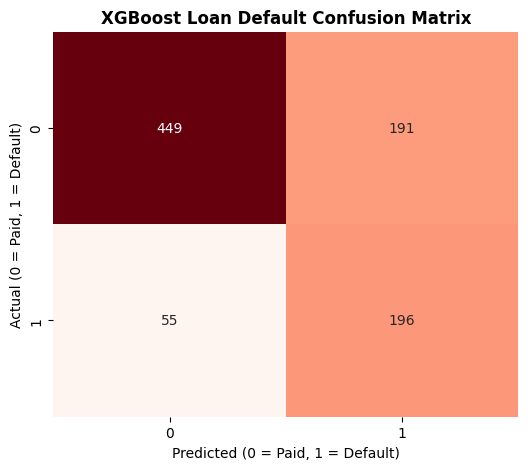


--- XGBOOST PERFORMANCE METRICS ---
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       640
           1       0.51      0.78      0.61       251

    accuracy                           0.72       891
   macro avg       0.70      0.74      0.70       891
weighted avg       0.78      0.72      0.74       891



In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions using the perfectly tuned model
y_pred = final_xgb.predict(X_test)

# 1. Plot the Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('XGBoost Loan Default Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted (0 = Paid, 1 = Default)')
plt.ylabel('Actual (0 = Paid, 1 = Default)')
plt.show()

# 2. Print the Classification Report
print("\n--- XGBOOST PERFORMANCE METRICS ---")
print(classification_report(y_test, y_pred))

## 3. Evaluation & Explainable AI (SHAP)
Because banking regulations require transparency, we cannot use a "black box" model. We evaluate the model's ability to catch defaults using a Confusion Matrix, and then apply **SHAP (SHapley Additive exPlanations)** to reverse-engineer the XGBoost model. This proves mathematically which financial behaviors (e.g., Seniority, Income) drove the final loan decisions.

Calculating SHAP values... (This might take a few seconds)


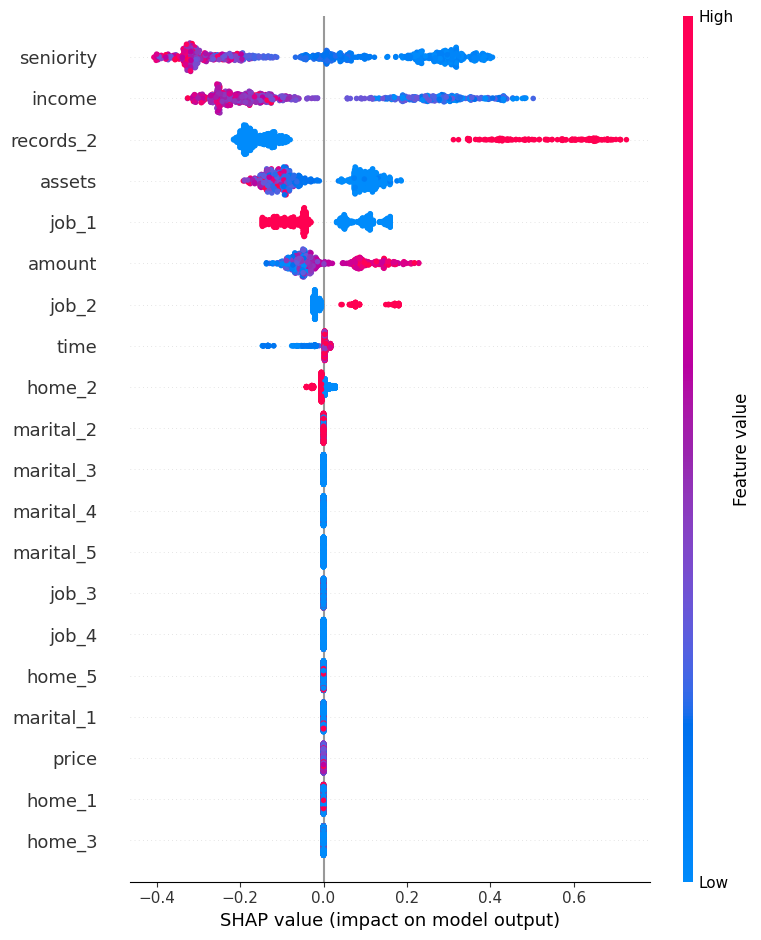

In [17]:
# 1. Install the SHAP library (it doesn't come pre-installed in Colab)
!pip install -q shap

import shap

# Initialize JavaScript visualization for SHAP (helpful for some plots)
shap.initjs()

# 2. Initialize the SHAP TreeExplainer with our final XGBoost model
print("Calculating SHAP values... (This might take a few seconds)")
explainer = shap.TreeExplainer(final_xgb)

# 3. Calculate the SHAP values for the Test dataset
shap_values = explainer.shap_values(X_test)

# 4. Generate the SHAP Summary Plot
# This is the visualization that you put in your portfolio and presentation slides!
shap.summary_plot(shap_values, X_test)